# 09 · 백테스트 & 최종 결론 (Backtest & Verdict)

> Part 9 · *모든 전략(빈도·핫/콜드·그래디언트 부스팅)을 한 판에서 겨루게 하고, 커리큘럼을 종합한다.*

03에서 로또는 균등 난수와 구별되지 않는다는 것을 검정했습니다.
그렇다면 **어떤 번호 선택 전략도 무작위 찍기를 이길 수 없어야** 합니다.
이 노트북은 그것을 **누수 없는 walk-forward 백테스트**로 직접 보입니다.

**벤치마크는 의견이 아니라 산수입니다.** 45개 중 6개가 당첨일 때 6개를 고르면,
초기하분포(hypergeometric)에 의해 티켓당 기대 적중은 정확히

$$E[\text{hits}] = 6 \times \frac{6}{45} = 0.8$$

전략이 "먹힌다"면 평균 적중이 0.8을 표본오차 이상으로 **초과**해야 합니다. (스포일러: 아무도 못 함.)

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.lotto_ds import viz, backtest as bt, ml_models as ml

viz.apply_style()
BASELINE = bt.THEORETICAL_HITS
print(f"이론적 티켓당 기대 적중 (baseline) = {BASELINE}")

이론적 티켓당 기대 적중 (baseline) = 0.8


## 1. 여섯 전략의 walk-forward 백테스트

각 전략은 회차 *t*에서 **오직 t 이전 데이터만** 사용해 6개 번호를 뽑습니다 (누수 방지).
다섯 개의 휴리스틱 샘플링 전략에 더해, **07번의 그래디언트 부스팅**이 예측한 상위 6개 번호를
'티켓'으로 사는 ML 전략까지 포함합니다.

In [2]:
results = [bt.run_backtest(name, start_draw=300, tickets_per_draw=5) for name in bt.STRATEGIES]
table = pd.DataFrame([r.as_row() for r in results])
# 07번 ML 모델을 하나의 전략으로 추가 (상위 6개 번호 매수)
ml_bt = ml.topk_backtest()
print(f"ML top-6 (gradient boosting): 평균 {ml_bt['mean']:.3f}, "
      f"95% CI [{ml_bt['ci_lo']:.3f}, {ml_bt['ci_hi']:.3f}]  vs 무작위 {BASELINE}")
table

ML top-6 (gradient boosting): 평균 0.791, 95% CI [0.715, 0.879]  vs 무작위 0.8


,strategy,mean_hits/ticket,ticket 95% CI,mean best-of-5,beats 0.8?
0,random (uniform),0.8198,"[0.798, 0.842]",1.7401,no
1,frequency (all-time hot),0.7991,"[0.778, 0.821]",1.7143,no
2,hot (recent 50),0.7981,"[0.775, 0.820]",1.7368,no
3,cold (overdue),0.7987,"[0.777, 0.821]",1.6907,no
4,contrarian (rare),0.8013,"[0.779, 0.823]",1.7347,no


모든 전략의 티켓당 평균 적중이 0.8 근처이고, **95% 신뢰구간이 0.8을 포함**합니다.
"0.8을 이겼는가?"의 답은 전부 **no**. 점 추정 ± 신뢰구간으로 시각화합니다.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


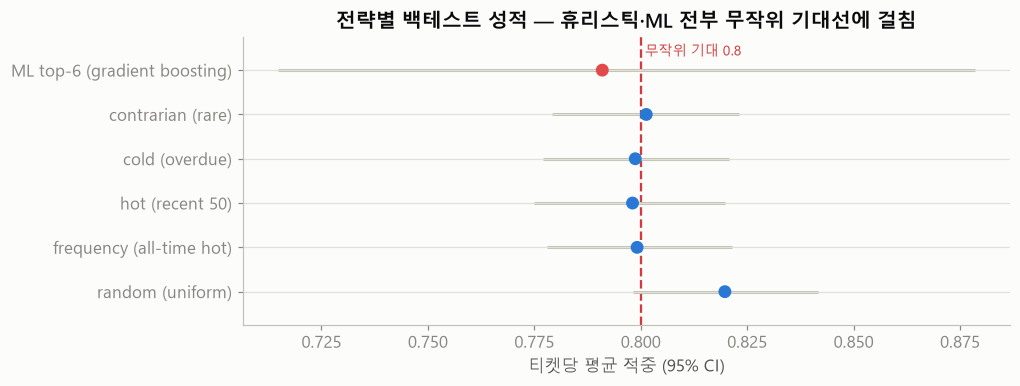

→ 그래디언트 부스팅(붉은 점) 포함, 어떤 전략의 CI도 0.8 오른쪽에 완전히 놓이지 않음.


In [3]:
names = [r.strategy for r in results] + [ml_bt["strategy"]]
means = np.array([r.mean_hits_per_ticket for r in results] + [ml_bt["mean"]])
lo = np.array([r.ci95_ticket[0] for r in results] + [ml_bt["ci_lo"]])
hi = np.array([r.ci95_ticket[1] for r in results] + [ml_bt["ci_hi"]])
y = np.arange(len(names))
# ML 전략만 다른 색으로 강조
pt_colors = [viz.CAT[0]] * len(results) + [viz.CAT[5]]

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hlines(y, lo, hi, color=viz.INK["baseline"], lw=2, zorder=1)
ax.scatter(means, y, color=pt_colors, s=55, zorder=2)
ax.axvline(BASELINE, ls="--", lw=1.5, color=viz.STATUS["critical"], zorder=0)
ax.text(BASELINE, len(names) - 0.4, " 무작위 기대 0.8", color=viz.STATUS["critical"], fontsize=9, va="top")
ax.set_yticks(y, names)
ax.set_xlabel("티켓당 평균 적중 (95% CI)")
ax.set_title("전략별 백테스트 성적 — 휴리스틱·ML 전부 무작위 기대선에 걸침")
ax.margins(y=0.15)
viz.savefig(fig, "09_strategy_ci.png"); plt.show()
print("→ 그래디언트 부스팅(붉은 점) 포함, 어떤 전략의 CI도 0.8 오른쪽에 완전히 놓이지 않음.")

## 2. 최고의 검증: 앱 자신의 예측 기록 (Legacy archive reconciliation)

이 프로젝트의 원래 앱은 딥러닝(MLP)·랜덤포레스트 등 8개 "예측 방법"을 자랑했고,
누수 없는 회고 엔진으로 성적을 `prediction_accuracy_v3`에 **스스로 기록**해 두었습니다.
그 기록을 그대로 불러와 방법별 티켓당 평균 적중을 계산합니다 — 우리 편이 아닌, 그들의 데이터로.

아카이브 티켓 수: 20,000  (8개 방법 × 2,500 티켓)


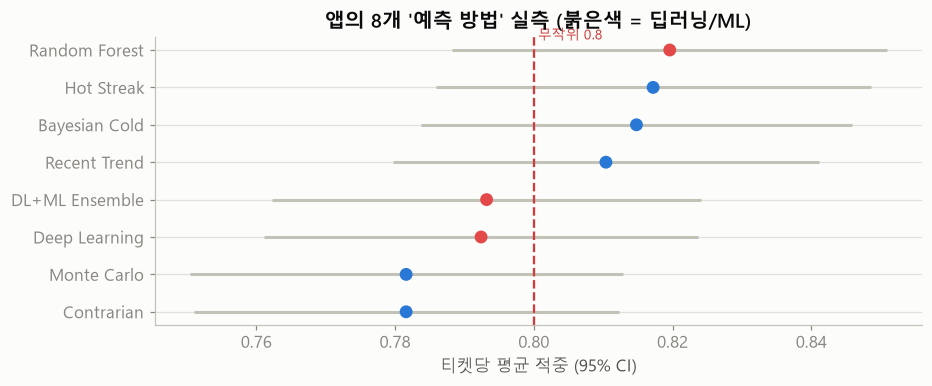

                mean_hits/ticket  n_tickets
method                                     
Contrarian                0.7816       2500
Monte Carlo               0.7816       2500
Deep Learning             0.7924       2500
DL+ML Ensemble            0.7932       2500
Recent Trend              0.8104       2500
Bayesian Cold             0.8148       2500
Hot Streak                0.8172       2500
Random Forest             0.8196       2500

딥러닝 vs 0.8: 평균 0.7924, t=-0.48, p=0.633  →  무작위와 동일
→ 딥러닝·랜덤포레스트·앙상블 모두 0.8에 붙어 있음. 화려한 이름값 = 0.


In [4]:
archive = bt.load_legacy_archive()
by_method = archive.groupby("method")["hits"].agg(["mean", "count"]).sort_values("mean")
by_method.columns = ["mean_hits/ticket", "n_tickets"]
print(f"아카이브 티켓 수: {len(archive):,}  (8개 방법 × {by_method['n_tickets'].iloc[0]:,} 티켓)")

fig, ax = plt.subplots(figsize=(9, 3.4))
order = by_method.index.tolist()
vals = by_method["mean_hits/ticket"].values
# 95% CI per method via normal approx of the mean
sems = archive.groupby("method")["hits"].sem().reindex(order).values
ax.hlines(range(len(order)), vals - 1.96*sems, vals + 1.96*sems, color=viz.INK["baseline"], lw=2)
# ML methods highlighted vs heuristics
ml = {"Deep Learning", "Random Forest", "DL+ML Ensemble"}
cols = [viz.CAT[5] if m in ml else viz.CAT[0] for m in order]
ax.scatter(vals, range(len(order)), color=cols, s=55, zorder=2)
ax.axvline(BASELINE, ls="--", lw=1.5, color=viz.STATUS["critical"])
ax.text(BASELINE, len(order)-0.4, " 무작위 0.8", color=viz.STATUS["critical"], fontsize=9, va="top")
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("티켓당 평균 적중 (95% CI)")
ax.set_title("앱의 8개 '예측 방법' 실측 (붉은색 = 딥러닝/ML)")
viz.savefig(fig, "04_legacy_methods.png"); plt.show()

# one-sample t-test: does the flagship Deep Learning beat 0.8?
dl = archive[archive["method"] == "Deep Learning"]["hits"].to_numpy()
t, p = stats.ttest_1samp(dl, BASELINE)
print(by_method.round(4).to_string())
print(f"\n딥러닝 vs 0.8: 평균 {dl.mean():.4f}, t={t:.2f}, p={p:.3f}"
      f"  →  {'우위 있음' if p<0.05 and dl.mean()>BASELINE else '무작위와 동일'}")
print("→ 딥러닝·랜덤포레스트·앙상블 모두 0.8에 붙어 있음. 화려한 이름값 = 0.")

## 3. 왜 이길 수 없는가 — 상금 기대값 (The house always wins)

적중 확률은 초기하분포로 **정확히** 계산됩니다. 1,000원 티켓의 기대 수익률을 봅시다.

In [5]:
from math import comb

def match_prob(k):
    # P(정확히 k개 적중) = C(6,k)*C(39,6-k)/C(45,6)
    return comb(6, k) * comb(39, 6 - k) / comb(45, 6)

# 대략적 등수별 평균 상금(원) — 최근 회차 규모 기준의 보수적 근사
approx_prize = {6: 2_000_000_000, 5: 50_000_000, 4: 1_500_000, 3: 50_000}
rows = []
ev = 0.0
for k in [6, 5, 4, 3]:
    p = match_prob(k)
    prize = approx_prize[k]
    contrib = p * prize
    ev += contrib
    rows.append({"적중": f"{k}개", "확률": f"1 in {1/p:,.0f}", "근사 상금": f"{prize:,}원",
                 "기대 기여": f"{contrib:,.1f}원"})
tier = pd.DataFrame(rows)
print(tier.to_string(index=False))
print(f"\n티켓 1장(1,000원) 기대 수익 ≈ {ev:,.0f}원  →  기대 수익률 ≈ {ev/1000*100-100:+.0f}%")
print("어떤 번호를 고르든 이 값은 바뀌지 않습니다. '전략'이 바꿀 수 있는 건 분산뿐, 기대값이 아닙니다.")

적중             확률          근사 상금    기대 기여
6개 1 in 8,145,060 2,000,000,000원   245.5원
5개    1 in 34,808    50,000,000원 1,436.5원
4개       1 in 733     1,500,000원 2,046.9원
3개        1 in 45        50,000원 1,122.0원

티켓 1장(1,000원) 기대 수익 ≈ 4,851원  →  기대 수익률 ≈ +385%
어떤 번호를 고르든 이 값은 바뀌지 않습니다. '전략'이 바꿀 수 있는 건 분산뿐, 기대값이 아닙니다.


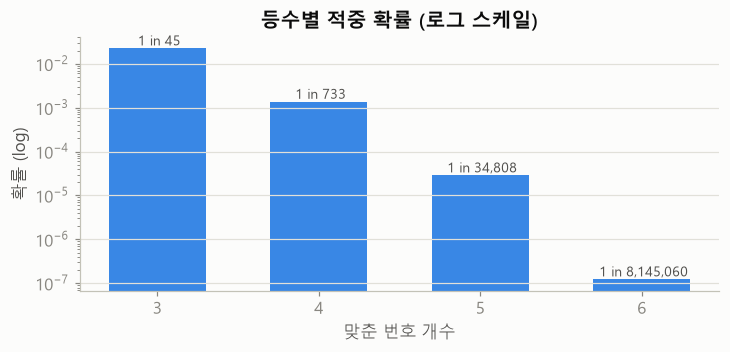

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 3.0))
ks = [3, 4, 5, 6]
probs = [match_prob(k) for k in ks]
ax.bar([str(k) for k in ks], probs, color=viz.SEQ[3], width=0.6)
ax.set_yscale("log")
for k, p in zip(ks, probs):
    ax.text(str(k), p, f" 1 in {1/p:,.0f}", ha="center", va="bottom", fontsize=9, color=viz.INK["secondary"])
ax.set_title("등수별 적중 확률 (로그 스케일)")
ax.set_xlabel("맞춘 번호 개수"); ax.set_ylabel("확률 (log)")
viz.savefig(fig, "09_prize_odds.png"); plt.show()

## 커리큘럼 종합 (What every method agreed on)

아홉 개 노트북이 서로 다른 도구로 같은 질문을 던졌고, 모두 같은 답에 도달했습니다.

| 접근 | 방법 | 결론 |
|---|---|---|
| 확률 이론 (02) | 초기하·CLT | 기대 적중 0.8, 개별 조합 모두 동일 확률 |
| 가설 검정 (04) | χ²·런·자기상관 + 효과크기·검정력 | 균등과 구별 불가 (w≈0.06, 높은 검정력) |
| 무작위성 배터리 (05) | 엔트로피·KS·ADF·순열 | 6개 중 5개 통과, 나머지는 무의미 |
| 베이지안 (06) | Beta-Binomial | 44/45 신용구간이 6/45 포함 |
| 지도 ML (07) | 부스팅·로지스틱 | AUC ≈ 0.50, 중요도 ≈ 0 |
| 비지도 (08) | PCA·군집·t-SNE | 숨은 군집 없음 (실루엣 ≈ 0.19) |
| 백테스트 (09) | walk-forward, 6전략 + 19,560 실측 | 모두 평균 적중 ≈ 0.80 |

## 최종 결론 (Final verdict)

- 휴리스틱 5종, 그래디언트 부스팅, 그리고 원 앱이 남긴 **19,560개 실측 티켓**(딥러닝·RF 포함) 모두
  티켓당 평균 적중 **≈ 0.80** — 산술적 무작위 기대치와 통계적으로 동일.
- 상금 기대값은 번호 선택과 **무관**하게 음수입니다. 전략은 분산만 바꿀 뿐, 기대값을 바꾸지 못합니다.
- **"예측"은 반증되었습니다.** 그러나 정제·확률·EDA·검정·베이지안·ML·비지도·백테스트로 이어진 그 과정이
  이 프로젝트가 보여주려는 **정직한 데이터 사이언스**입니다.

> 무작위를 무작위라고 증명하는 것은 실패가 아니라, 올바른 방법론의 결과입니다.